In [38]:
import pandas as pd 
import re
import emoji 
from pathlib import Path 
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter

# Configuration des graphiques
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (12, 6)
data_dir = Path('../data')
resume_dataset=pd.read_csv(data_dir/'interim/combined_resume_final.csv')
# resume_dataset2=pd.read_csv(data_dir/'raw/UpdatedResumeDataSet.csv')


In [39]:
#Lecture et affichage Information dataframme
def read_data(data):
    print("\n __Aperçu des données :")
    print(data.head(3))
    # Afficher les informations sur le DataFrame
    print("\n __Informations sur les données :")
    print(data.info())
    print(" \n __Taille : \n",data.shape)
    print("\n __Information sur les Categories: \n",data['Category'].value_counts().reset_index())

#### Lecture et affichage des donnees

In [40]:
resume_dataset.head()

,Category,Resume
0,Database Administrator,"Ability: Installation and Building Server, Run..."
1,Database Administrator,Ability: database management systems administr...
2,Oracle Database Administrator,Ability: Over 4+ years of Experience as Archit...
3,Oracle Database Administrator,"Ability: Oracle Database Administration, Datab..."
4,Oracle Database Administrator,"Ability: Oracle Database Administration, Oracl..."


##### Exploration des donnees

In [41]:
category_counts = resume_dataset['Category'].value_counts()
# rare_categories = category_counts[category_counts < 10].index
print(f"\nNombre de catégories rares (moins de 9 occurrences): {len(category_counts.index)}")
print("\nListe des catégories :")
print(category_counts.index.sort_values())


Nombre de catégories rares (moins de 9 occurrences): 220

Liste des catégories :
Index(['AEM Developer', 'Administrative Assistant', 'Advocate',
       'Android Application Developer', 'Android Developer',
       'Application Developer', 'Arts', 'Automation Testing',
       'Backend Developer', 'Blockchain',
       ...
       'Technical Consultant', 'Technical Project Manager', 'Testing',
       'UI Developer', 'UI Developer UI Developer UI Developer',
       'UI/ Front End Developer', 'Web Designing', 'Web Developer',
       'Web Developer Web Developer Web Developer',
       'Web_Developer,Software_Developer'],
      dtype='object', name='Category', length=220)


#####  ----Distribution des catégories (top 30)

In [42]:
# import squarify
# plt.figure(figsize=(16, 8))
# squarify.plot(sizes=category_dist.values, label=category_dist.index, alpha=0.8)
# plt.axis('off')
# plt.title('Répartition des catégories (Treemap)')
# plt.show()

In [43]:

# # Calcul de la longueur des textes
# new__resume_dataset['text_length'] = new__resume_dataset['Resume'].apply(len)

# # Top 20 des catégories les plus fréquentes
# top_categories = new__resume_dataset['Category'].value_counts().nlargest(30).index

# # Filtrage des données
# plot_data = new__resume_dataset[new__resume_dataset['Category'].isin(top_categories)]

/tmp/ipykernel_6126/3843341409.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  bar = sns.barplot(x=top_cats.values, y=top_cats.index, palette="viridis", ax=ax1)


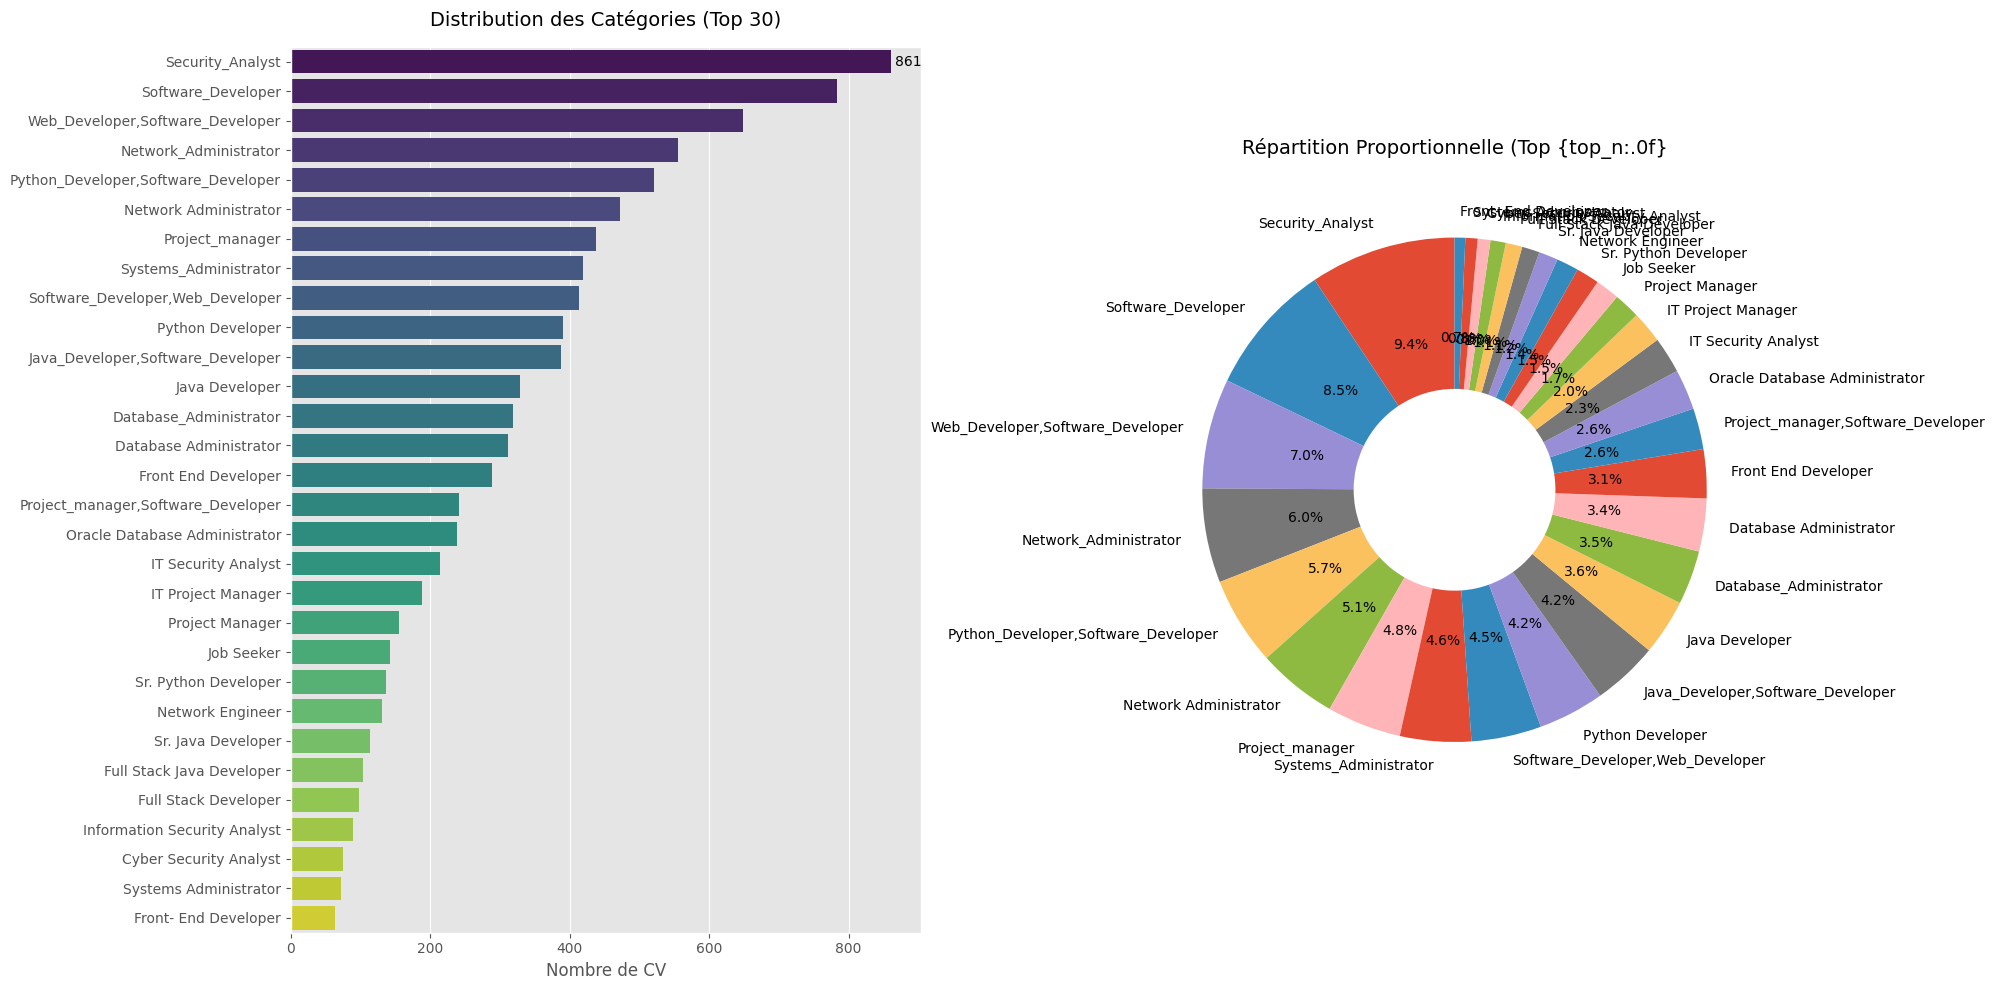

In [44]:
new__resume_dataset=resume_dataset.copy(deep=True)
def plot_category_distribution(data, top_n, figsize=(20, 10)):
    """
    Affiche la distribution des catégories sous forme de barplot et pie chart
    """
    plt.figure(figsize=figsize)
    grid = plt.GridSpec(1, 2, width_ratios=[1.5, 1.5])

    # 1. Barplot hiérarchique (Top 15)
    ax1 = plt.subplot(grid[0])
    top_cats = data['Category'].value_counts().nlargest(top_n)
    bar = sns.barplot(x=top_cats.values, y=top_cats.index, palette="viridis", ax=ax1)
    ax1.set_title('Distribution des Catégories (Top 30)', fontsize=14, pad=15)
    ax1.set_xlabel('Nombre de CV', fontsize=12)
    ax1.set_ylabel('')
    ax1.bar_label(bar.containers[0], fmt='%d', padding=3, fontsize=10)

    # 2. Pie Chart (Top 10)
    ax2 = plt.subplot(grid[1])
    top_10 = data['Category'].value_counts().nlargest(top_n)
    top_10.plot.pie(autopct='%1.1f%%', startangle=90, ax=ax2, 
                    wedgeprops={'width':0.6}, textprops={'fontsize':10})
    ax2.set_title('Répartition Proportionnelle (Top {top_n:.0f}', fontsize=14, pad=15)
    ax2.set_ylabel('')


    plt.tight_layout()
    plt.show()

plot_category_distribution(new__resume_dataset,30)

In [45]:
#####  ----Distribution de la longueur des CV par catégorie

/tmp/ipykernel_6126/9861235.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  bar = sns.barplot(x=mean_by_category.head(n_categories).values,


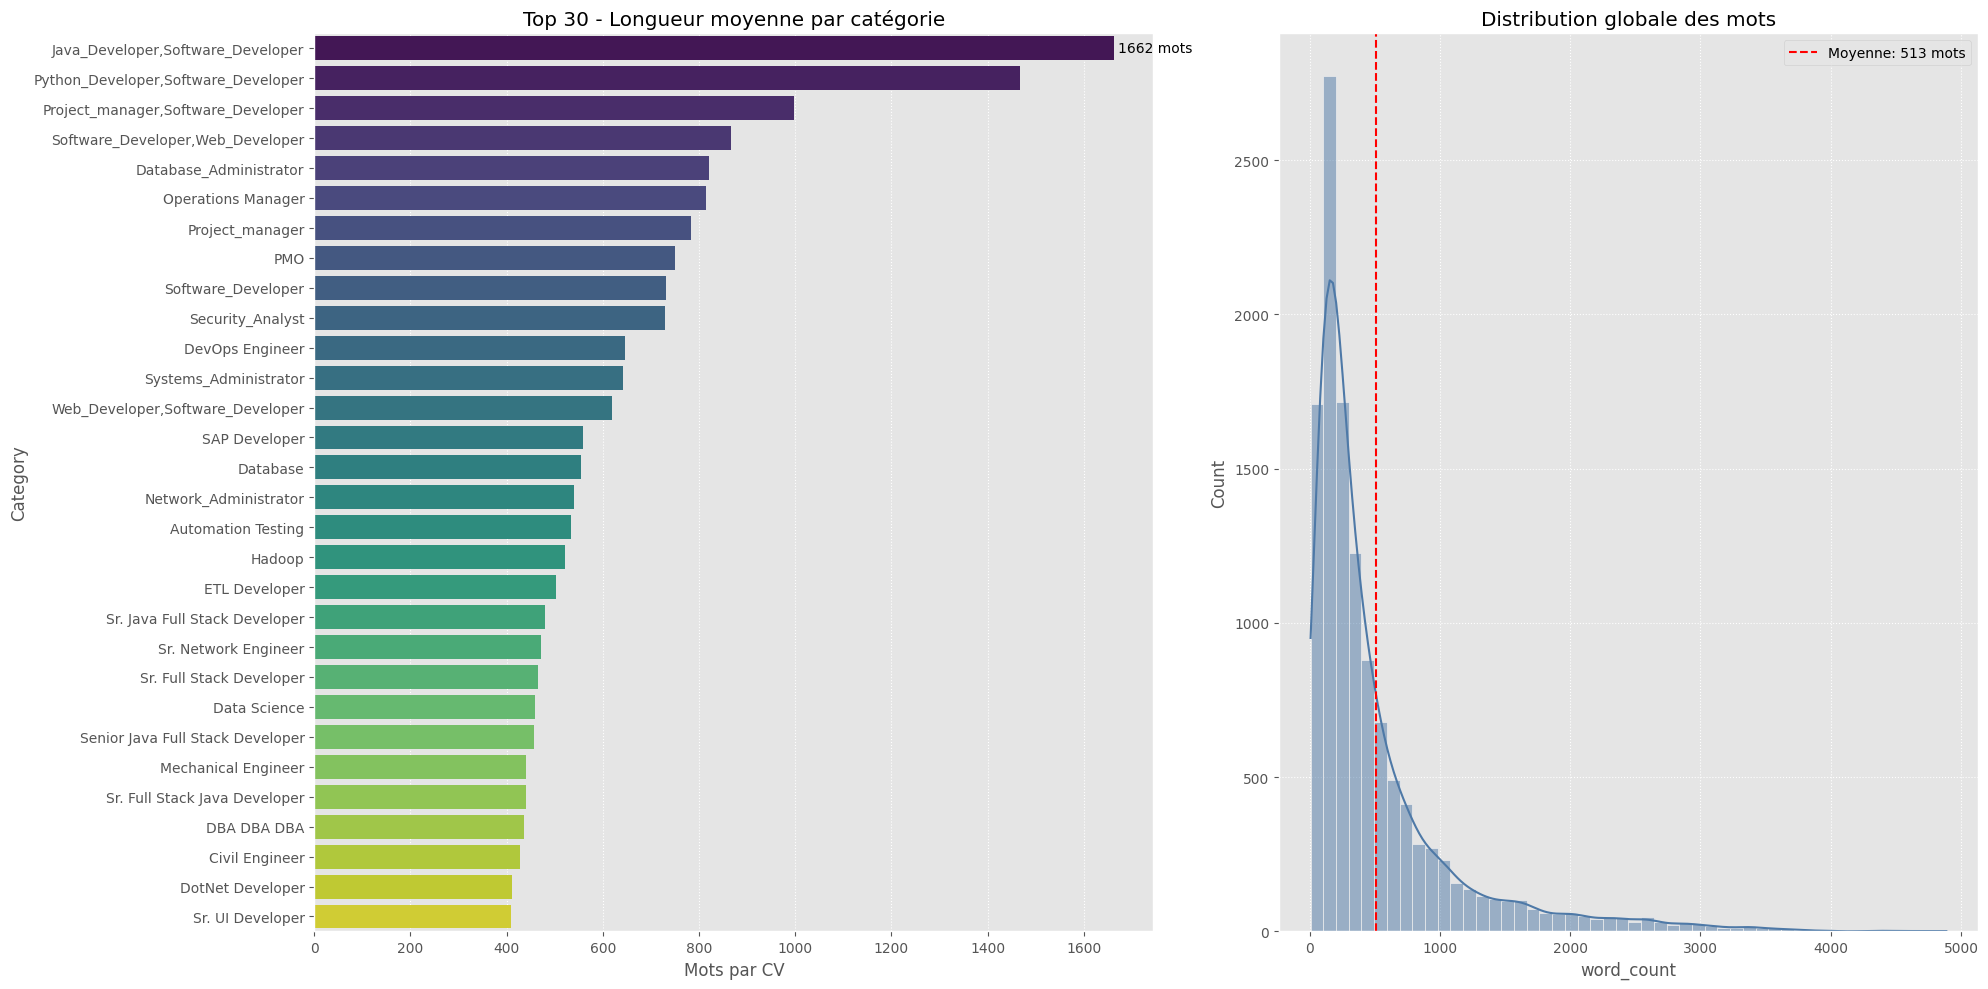

In [46]:
def plot_cv_length_analysis(df, n_categories=30, figsize=(20, 10)):
    """
    Analyse visuelle de la longueur des CV par mots
    """
    # Calcul des métriques
    df = df.copy()
    df['word_count'] = df['Resume'].apply(lambda x: len(x.split()))
    mean_by_category = df.groupby('Category')['word_count'].mean().sort_values(ascending=False)
    global_mean = df['word_count'].mean()
    
    # Création de la figure
    plt.figure(figsize=figsize)
    grid = plt.GridSpec(1, 2, width_ratios=[1.2, 1])
    
    # 1. Barplot des catégories les plus longues
    ax1 = plt.subplot(grid[0])
    bar = sns.barplot(x=mean_by_category.head(n_categories).values,
                     y=mean_by_category.head(n_categories).index,
                     palette="viridis")
    ax1.bar_label(bar.containers[0], fmt='%.0f mots', padding=3)
    ax1.set_title(f'Top {n_categories} - Longueur moyenne par catégorie')
    ax1.set_xlabel('Mots par CV')
    ax1.grid(axis='x', linestyle=':')
    
    # 2. Distribution globale
    ax2 = plt.subplot(grid[1])
    hist = sns.histplot(df['word_count'], bins=50, kde=True, color='#4e79a7')
    ax2.axvline(global_mean, color='red', linestyle='--', 
                label=f'Moyenne: {global_mean:.0f} mots')
    ax2.set_title('Distribution globale des mots')
    ax2.legend()
    ax2.grid(linestyle=':')
    
    plt.tight_layout()
    plt.show()

plot_cv_length_analysis(new__resume_dataset, 30)

### DATASET APRES PREPROCESSING

In [47]:
cleaned_resume_dataset=pd.read_csv(data_dir/'processed/cleaned_combined_resume_final.csv')
# resume_dataset=pd.read_csv(data_dir/'interim/combined_resume_final.csv')
category_counts = cleaned_resume_dataset['Category'].value_counts()
# rare_categories = category_counts[category_counts < 10].index
print(f"\nNombre de catégories : {len(category_counts.index)}")
print("\nListe des catégories  :")
print(category_counts.index.sort_values())


Nombre de catégories : 46

Liste des catégories  :
Index(['Big Data Cloud Developer', 'Consultant', 'Cyber Security Analyst',
       'Data Scientist', 'Database Administrator', 'Freelance Developer',
       'Front End Developer', 'Front End Web Developer', 'Front-End Developer',
       'Full Stack Developer', 'Full Stack Java Developer',
       'Information Security Analyst', 'It Manager', 'Java Developer',
       'Java Developer,Software Developer', 'Java Full Stack Developer',
       'Java/J2Ee Developer', 'Job Seeker', 'Mobile Developer',
       'Network Administrator', 'Network Engineer',
       'Oracle Database Administrator', 'Other IT', 'Other No IT',
       'Project Manager', 'Project Manager,Software Developer',
       'Python Developer', 'Python Developer,Software Developer',
       'Security Analyst', 'Senior Database Administrator',
       'Senior Front End Developer', 'Senior Java Developer',
       'Senior Java Full Stack Developer', 'Senior Java/J2Ee Developer',
       

/tmp/ipykernel_6126/3843341409.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  bar = sns.barplot(x=top_cats.values, y=top_cats.index, palette="viridis", ax=ax1)


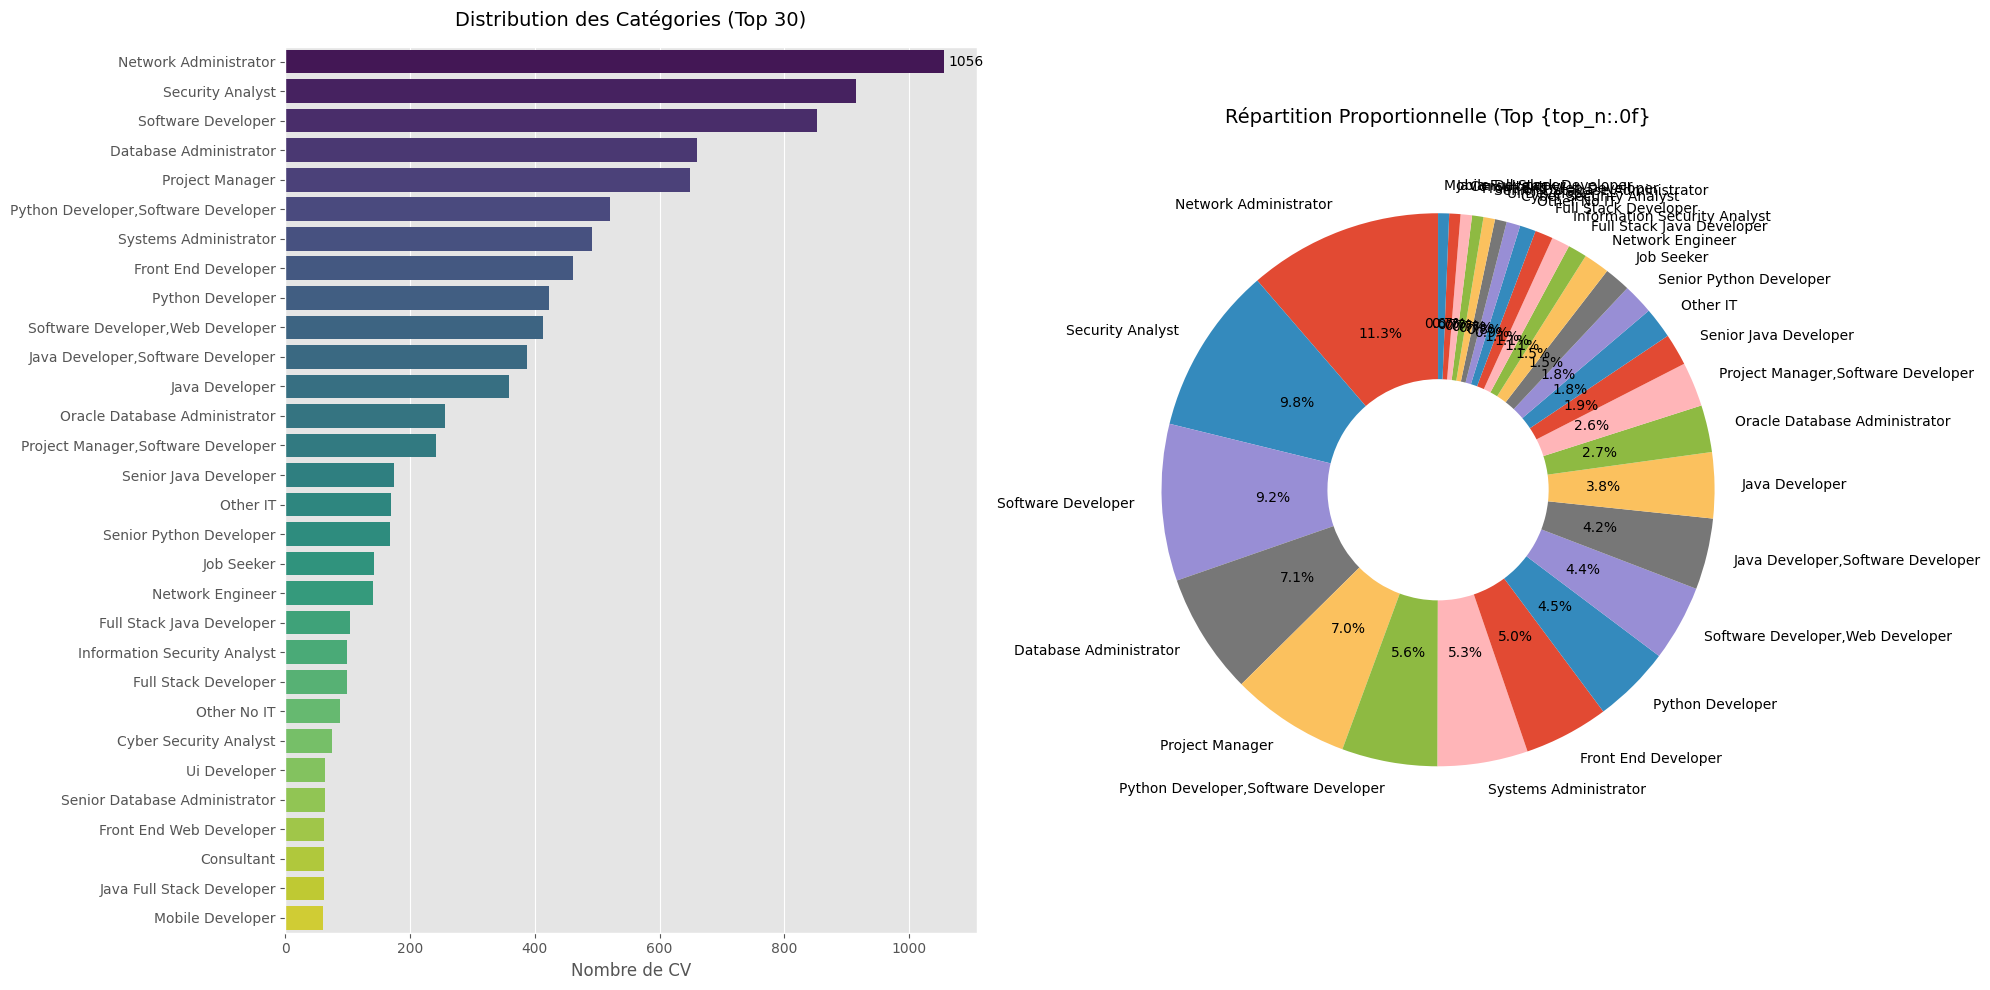

In [48]:
plot_category_distribution(cleaned_resume_dataset,30)

/tmp/ipykernel_6126/9861235.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  bar = sns.barplot(x=mean_by_category.head(n_categories).values,


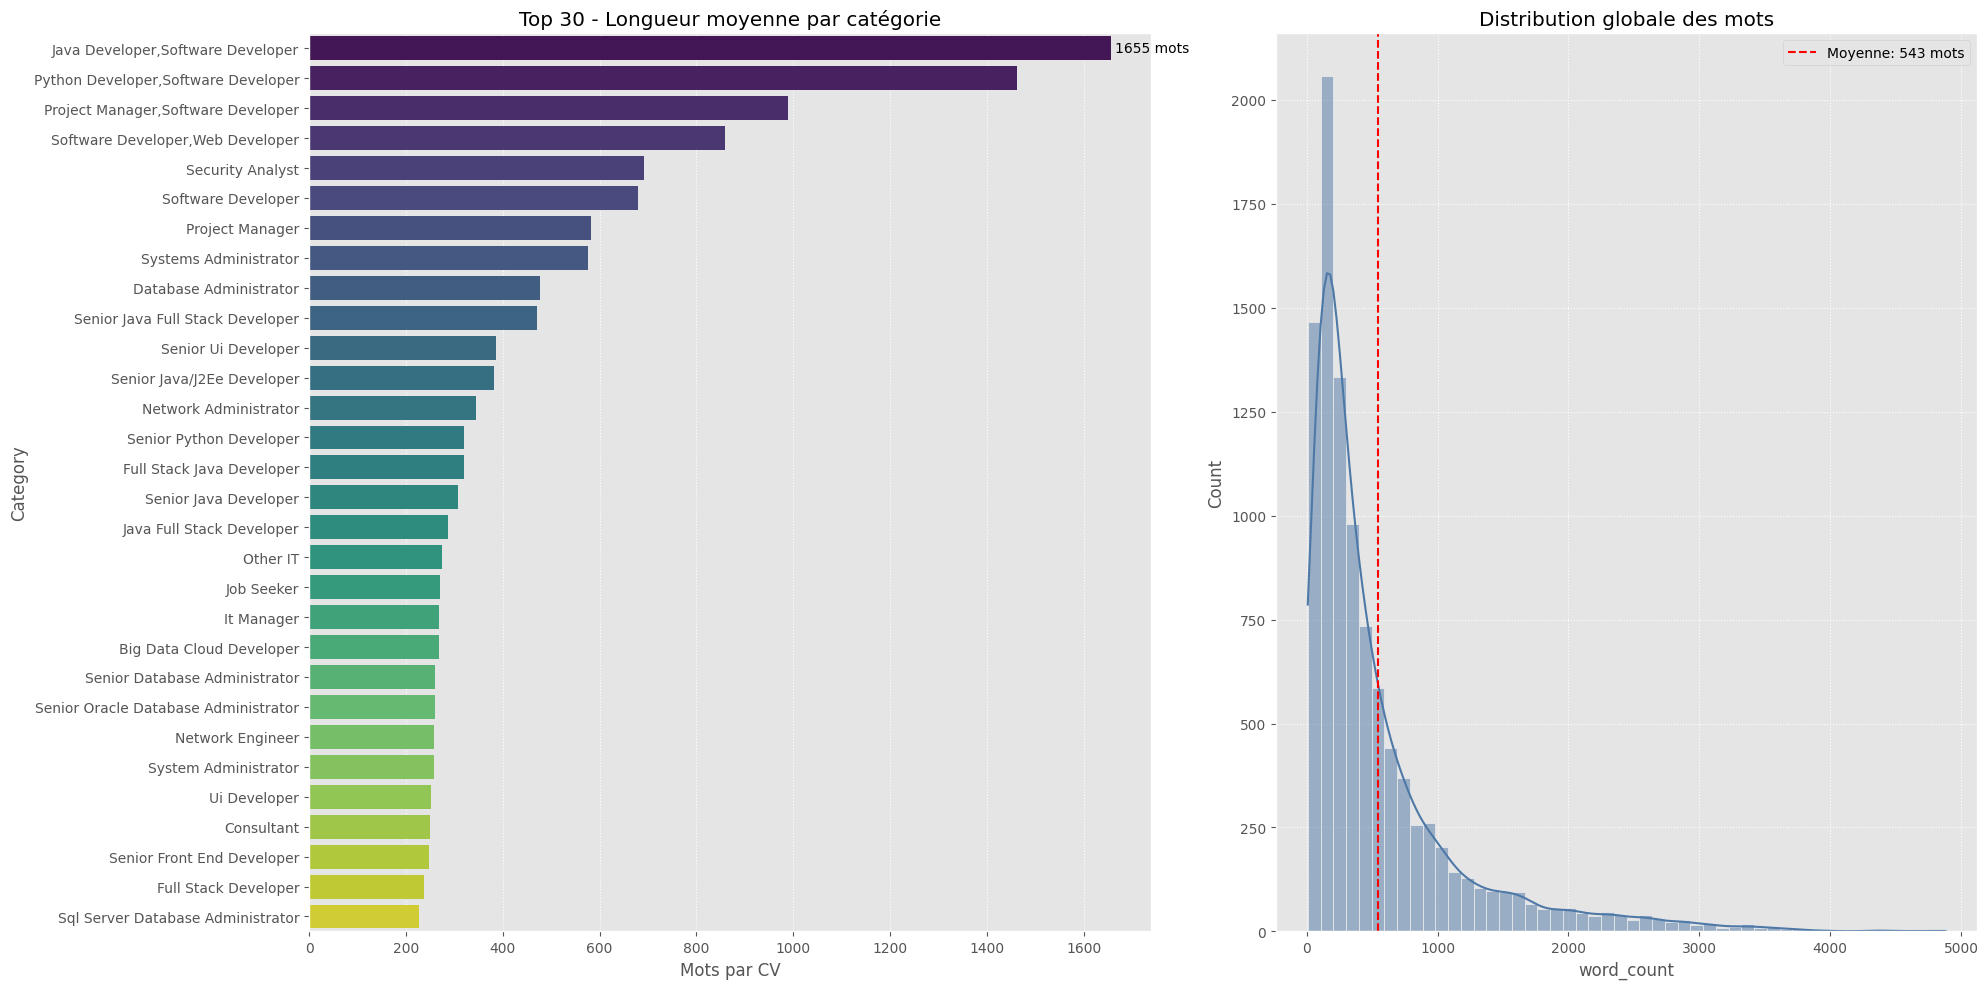

In [49]:
plot_cv_length_analysis(cleaned_resume_dataset, 30)